# K01 — What TESSERA actually has over Kenya

**Start here.** Later notebooks in this series rely on the coverage facts
established below, and on the tile catalogue `data/kenya_tiles.csv` built by
[`data/build_catalogue.py`](../data/build_catalogue.py).

---

## Why a whole notebook on coverage?

Because the answer decides what a country programme can and cannot do, and it
is *not* the same everywhere: TESSERA's coverage varies by country and by year.
Before planning any change detection over Kenya, it is worth establishing with
numbers what actually exists here.

The short version, proved below:

- **4,766 tiles cover Kenya**, the entire country, edge to edge.
- **Every one of them carries all nine years, 2017–2025.** Not most. All 4,766.
- So the constraint on a Kenya programme is not data availability. It is
  knowing where the *landmask* misleads you, which §4 shows it does, in a way
  that is specific to Kenya's lakes.

Sections 1–3 are catalogue lookups and download nothing. Section 4 fetches
seven tiles and section 5 two more tile-years: about 1.5 GB on a cold cache
(~163 MB per tile-year), into `global_0.1_degree_representation/`.

In [1]:
# ---------------------------------------------------------------------------
# SETUP
# ---------------------------------------------------------------------------
# Nothing in this cell downloads land data. Building the client only fetches a
# small catalogue file listing which tiles exist — which is all that sections
# 1 to 3 need. The first actual download happens in section 4.

import sys
from collections import Counter
from pathlib import Path

import numpy as np                    # array maths
import pandas as pd                   # the tile catalogue, as a table
import geopandas as gpd               # the same, but aware of country borders
import matplotlib.pyplot as plt       # every figure below
from matplotlib.lines import Line2D   # hand-built legend entries
from matplotlib.patches import Patch  # ditto, for filled swatches
from matplotlib.colors import ListedColormap   # explicit two-colour maps
from shapely.geometry import Point    # point-in-country tests

# Jupyter may start in the repo root or in experiments/. Locate src/kenya.py
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "src" / "kenya.py").is_file()),
    None,
)
if repo_root is None:
    raise RuntimeError("Could not locate the repository root containing src/kenya.py")
sys.path.insert(0, str(repo_root / "src"))

import kenya as K           # shared helpers for this series — see src/kenya.py

# K.client() pins three things that must not vary across this series:
#   dataset_version="v1"     embeddings from different versions are not
#   dataset_variant="vultr"  comparable, so mixing them silently corrupts
#   embeddings_dir=...       every similarity and change result
gt = K.client()

print("dataset years available globally:", gt.registry.get_available_years())
print("Kenya bounding box used here:    ", K.KENYA_BBOX)

dataset years available globally: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Kenya bounding box used here:     (33.8, -4.8, 42.0, 5.6)


## 1. Counting tiles honestly

`gt.registry` can list every tile in a bounding box for a given year without
downloading anything — it is just a catalogue lookup.

The subtlety is the bounding box. Kenya's is `(33.8, -4.8, 42.0, 5.6)`, and that
rectangle also contains large parts of Ethiopia, Somalia, South Sudan, Uganda
and Tanzania, plus a wide strip of the Indian Ocean. A bbox count would hand you
all of it.

So every tile centre gets tested against Kenya's actual polygon (Natural Earth
1:10m), and only tiles whose centre falls inside the country are counted. That
is exactly what [`data/build_catalogue.py`](../data/build_catalogue.py) did to
produce `data/kenya_tiles.csv`; the cell below re-derives the polygon so the
provenance of the numbers is visible rather than taken on trust.

In [2]:
# ---------------------------------------------------------------------------
# TILES PER YEAR — bounding box vs. the real border
# ---------------------------------------------------------------------------
# Natural Earth 1:10m country outlines, downloaded once by data/fetch_boundaries.py.
adm0 = gpd.read_file(repo_root / "data" / "ne_10m_admin0.geojson")

# Kenya as a single shape. A country can be several polygons (islands, exclaves),
# so union_all() merges them into one before we test points against it. This is
# the identical expression build_catalogue.py used, so `kenya_poly` documents
# where `inside` below came from.
kenya_poly = adm0[adm0.ADMIN == "Kenya"].geometry.union_all()

# The pre-built per-tile table: one row per tile centre INSIDE Kenya, with its
# province, agro-ecological zone, and the list of years it exists for.
cat = K.catalogue()
inside = set(zip(cat.lon, cat.lat))      # fast membership test

print("year   tiles in bbox   tiles in Kenya   bbox over-count")
for year in K.DEEP_YEARS:
    # load_blocks_for_region is a registry lookup — no pixels are downloaded.
    bbox_tiles = {(round(lon, 2), round(lat, 2)) for _, lon, lat
                  in gt.registry.load_blocks_for_region(K.KENYA_BBOX, year)}
    in_kenya = len(bbox_tiles & inside)
    print(f"{year}   {len(bbox_tiles):>13,}   {in_kenya:>14,}   "
          f"{len(bbox_tiles) / in_kenya:>14.2f}x")

# Sanity check the total against Kenya's real area. A 0.1-degree tile is ~11.1 km
# on a side near the equator, so ~123 km^2; Kenya is 580,367 km^2 in total, of
# which ~11,200 km^2 is inland water. Total is the right comparison rather than
# land area alone, because TESSERA covers inland water too — see section 4.
km2 = len(cat) * (0.1 * 111.32) ** 2
print(f"\n{len(cat):,} tiles x ~123 km^2 = ~{km2:,.0f} km^2 "
      f"vs Kenya's total area of 580,367 km^2")

year   tiles in bbox   tiles in Kenya   bbox over-count


2017           7,763            4,766             1.63x
2018           7,761            4,766             1.63x


2019           7,763            4,766             1.63x
2020           7,762            4,766             1.63x


2021           7,761            4,766             1.63x
2022           7,760            4,766             1.63x


2023           7,762            4,766             1.63x


2024           8,216            4,766             1.72x
2025           7,736            4,766             1.62x

4,766 tiles x ~123 km^2 = ~590,610 km^2 vs Kenya's total area of 580,367 km^2


Two things fall out of that table.

**Kenya is complete in every year.** 4,766 tiles, 2017 through 2025, with no
year weaker than any other. The area check is the real proof: 4,766 tiles is
~591,000 km² against Kenya's total area of 580,367 km², and the ~2% surplus is
exactly what you expect from tiles that straddle the border or the shoreline.
This is genuinely wall-to-wall.

**The bounding box still over-counts by ~1.6×**, and it will do that quietly.
The surplus is not error — those are real tiles over Ethiopia, Somalia, Uganda
and Tanzania. But if you scoped a Kenya project by counting tiles in a
rectangle you would plan for 63% more data than Kenya has, and a nationwide
mosaic built from the bbox would include several hundred kilometres of
neighbouring countries.

**Why 2024 is the odd row.** Every year shows ~7,760 tiles in the rectangle
except 2024, which shows 8,216 — but the "in Kenya" column is 4,766 in all nine
years. So the extra 454 tiles are entirely *outside* the border, and the next
cell confirms where: **319 in Ethiopia, 91 in South Sudan, 43 in Somalia**, and
one offshore. None in Kenya.

So 2024 simply reaches further into the neighbours than the other years do;
the other eight years stop partway across the northern borders. **Nothing about
Kenya itself changes between years**, which is the point of section 2.

Note this when reading the map below: it is drawn for **2024 only**, so its
8,216 is the largest of the nine numbers in the table, not a contradiction of
them.

**One honest caveat about clipping by centre.** The catalogue keeps a tile only
if its *centre* falls inside the Natural Earth polygon. On a ragged coast that
drops tiles which do carry Kenyan land — Mombasa is the clearest case. Its tile
`(39.65, -4.05)` exists in the registry and downloads fine, but the centre lands
in the Kilindini channel rather than on the island, so the catalogue does not
list it. If you are working the coast, query the registry directly rather than
filtering the catalogue.

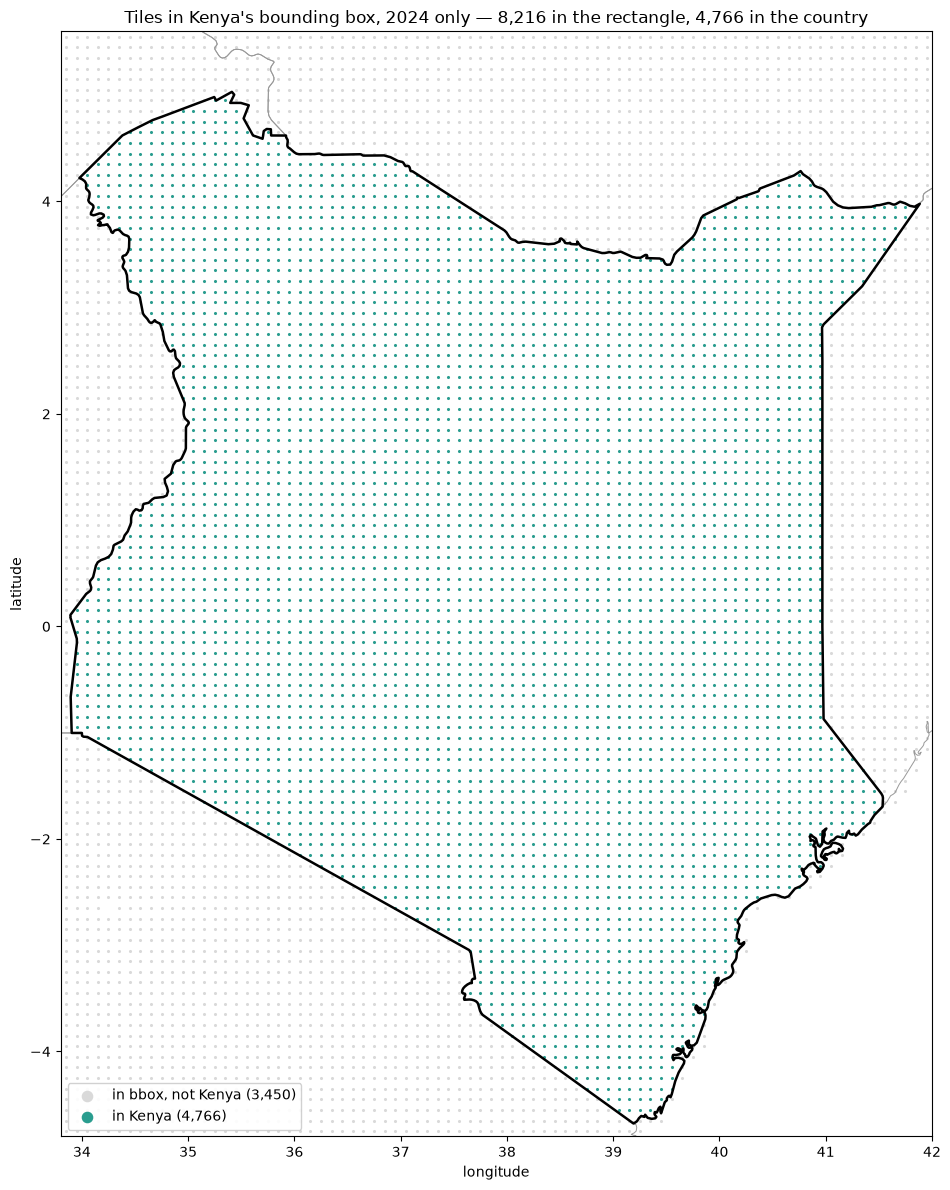

tiles present in 2024 but not 2017: 454
   319  Ethiopia
    91  South Sudan
    43  Somalia
     1  ocean / no country

...of which inside Kenya: 0


In [3]:
# ---------------------------------------------------------------------------
# THE BBOX SURPLUS, DRAWN — where do the extra tiles come from?
# ---------------------------------------------------------------------------
# The table says the bbox over-counts by 1.6x. This shows that the surplus is
# not a fringe along the border: it is five whole neighbouring countries.
fig, ax = plt.subplots(figsize=(11, 12))

neighbours = adm0[adm0.ADMIN != "Kenya"]

# Every tile centre in the rectangle for 2024, as an (n, 2) array of lon/lat.
tiles = np.array([[lon, lat] for _, lon, lat
                  in gt.registry.load_blocks_for_region(K.KENYA_BBOX, 2024)])
is_ke = np.array([(round(lo, 2), round(la, 2)) in inside for lo, la in tiles])

ax.scatter(*tiles[~is_ke].T, s=1.5, c="#d9d9d9", label=f"in bbox, not Kenya ({(~is_ke).sum():,})")
ax.scatter(*tiles[is_ke].T, s=1.5, c="#2a9d8f", label=f"in Kenya ({is_ke.sum():,})")

neighbours.boundary.plot(ax=ax, color="0.6", linewidth=0.7)
adm0[adm0.ADMIN == "Kenya"].boundary.plot(ax=ax, color="black", linewidth=1.8)

# Name the neighbours, so the grey mass is obviously other countries.
for _, row in neighbours.iterrows():
    pt = row.geometry.representative_point()
    if K.KENYA_BBOX[0] < pt.x < K.KENYA_BBOX[2] and K.KENYA_BBOX[1] < pt.y < K.KENYA_BBOX[3]:
        ax.annotate(row.ADMIN, (pt.x, pt.y), fontsize=8, color="0.35", ha="center")

ax.set_xlim(K.KENYA_BBOX[0], K.KENYA_BBOX[2]); ax.set_ylim(K.KENYA_BBOX[1], K.KENYA_BBOX[3])
ax.set_title(f"Tiles in Kenya's bounding box, 2024 only — "
             f"{len(tiles):,} in the rectangle, {is_ke.sum():,} in the country",
             fontsize=12)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.legend(loc="lower left", markerscale=6, framealpha=0.9)
plt.tight_layout(); plt.show()

# WHERE does 2024's surplus sit? Compare the 2024 tile set against a typical
# year and locate the difference, rather than asserting it is all foreign.
t24 = {(round(lo, 2), round(la, 2)) for _, lo, la
       in gt.registry.load_blocks_for_region(K.KENYA_BBOX, 2024)}
t17 = {(round(lo, 2), round(la, 2)) for _, lo, la
       in gt.registry.load_blocks_for_region(K.KENYA_BBOX, 2017)}

polys = {r.ADMIN: r.geometry for _, r in adm0.iterrows()}
counts = Counter()
for lon, lat in t24 - t17:
    hit = [name for name, geom in polys.items() if geom.contains(Point(lon, lat))]
    counts[hit[0] if hit else "ocean / no country"] += 1

print(f"tiles present in 2024 but not 2017: {len(t24 - t17)}")
for country, n in counts.most_common():
    print(f"  {n:>4}  {country}")
print(f"\n...of which inside Kenya: {counts.get('Kenya', 0)}")

The empty wedge in the southeast is the Indian Ocean — TESSERA is a land model
and does not generate tiles over open sea. Everything else in grey is a
neighbour, and the Kenyan green fills its outline completely.

## 2. How deep does it go?

Full coverage in one year is not the same as full coverage in every year. The
catalogue records the list of years per tile, so the question is one
`value_counts` away.

In [4]:
# ---------------------------------------------------------------------------
# YEAR-DEPTH: how many tiles have how many years?
# ---------------------------------------------------------------------------
depth = cat.n_years.value_counts().sort_index()

print("years available   tiles   share of Kenya")
for n, count in depth.items():
    bar = "#" * int(60 * count / depth.max())
    print(f"{n:>15}   {count:>5,}   {count / len(cat):>6.1%}  {bar}")

# Are all nine years the SAME nine years everywhere? A tile with nine years out
# of 2017-2025 must have all of them, but check the strings rather than infer
# it — a country-wide claim should not rest on arithmetic about a count.
print("\ndistinct year-lists present in the catalogue:")
for years, count in cat.years.value_counts().items():
    print(f"  {count:>5,} tiles   {years}")

years available   tiles   share of Kenya
              9   4,766   100.0%  ############################################################

distinct year-lists present in the catalogue:
  4,766 tiles   2017|2018|2019|2020|2021|2022|2023|2024|2025


**Every tile in Kenya has all nine years, and they are the same nine years.**
One year-list, 4,766 times over: `2017|2018|…|2025`.

That single line is the most consequential fact in this notebook. Where coverage
is patchy, choosing a study site means first finding a tile that happens to have
several years, then checking it still contains what you care about. None of that
applies here: in Kenya you pick the place, and the place has nine years, running
all the way to 2025.

The remaining question is therefore not *where can we work* but *is the
coverage evenly good*: a nationwide dataset can still be lopsided in ways that
bite later.

In [5]:
# ---------------------------------------------------------------------------
# COVERAGE BY ZONE AND PROVINCE
# ---------------------------------------------------------------------------
# With depth constant at 9, "how good is coverage here" collapses to "how many
# tiles are here", which is really a question about the size of each zone.
summary = (cat.groupby("zone")
             .agg(tiles=("lon", "size"),
                  deep_tiles=("multiyear", "sum"),
                  min_years=("n_years", "min"),
                  max_years=("n_years", "max"))
             .assign(share=lambda d: d.tiles / len(cat),
                     km2=lambda d: d.tiles * (0.1 * 111.32) ** 2)
             .sort_values("tiles", ascending=False))
print(summary.to_string(float_format=lambda v: f"{v:,.2f}"))

print("\nby province:")
print(cat.province.value_counts().to_string())

                         tiles  deep_tiles  min_years  max_years  share        km2
zone                                                                              
Arid & Semi-Arid (ASAL)   2323        2323          9          9   0.49 287,869.47
Highlands & Rift          1574        1574          9          9   0.33 195,052.32
Coast                      665         665          9          9   0.14  82,407.75
Lake Victoria Basin        204         204          9          9   0.04  25,279.97

by province:
province
Rift Valley      1456
Eastern          1278
North-Eastern    1045
Coast             665
Nyanza            137
Central           111
Western            67
Nairobi             7


The `min_years` / `max_years` columns are there to be boring, and they are: 9
and 9 in every zone. There is no lopsidedness to find.

What the table does show is the shape of the country rather than the shape of
the dataset. Nearly half of Kenya's tiles (2,323, 49%) are in the arid and
semi-arid zone, and only 204 (4%) are in the Lake Victoria basin, one of the
most densely populated and farmed parts of the country. That is a real asymmetry, but it belongs to
Kenya, not to TESSERA, and it is a useful warning for anything that samples
tiles uniformly: a random sample of Kenyan tiles is mostly desert.

**A note on the map below, and on the stars.** The Lake Victoria basin is the
zone readers hunt for and cannot find: it is 4% of the tiles, squeezed into the
far west between roughly 34.0°E and 35.2°E, so it is annotated explicitly and
drawn in a deliberately loud purple with larger dots.

The white stars are **`K.SITES`** — the twenty-four named places this series
works with, listed with coordinates and a one-line description at the bottom of
[`src/kenya.py`](../src/kenya.py). They are ordinary Kenyan locations chosen to span the
country's land systems: the Rift lakes, Mount Kenya, the Mau, Nairobi, Mombasa,
the Tana delta, Turkana, the Mara. Nothing in the coverage analysis depends on
them — they are there so every later notebook argues about the same places, and
so section 3 can check that each one really does sit on a nine-year tile.

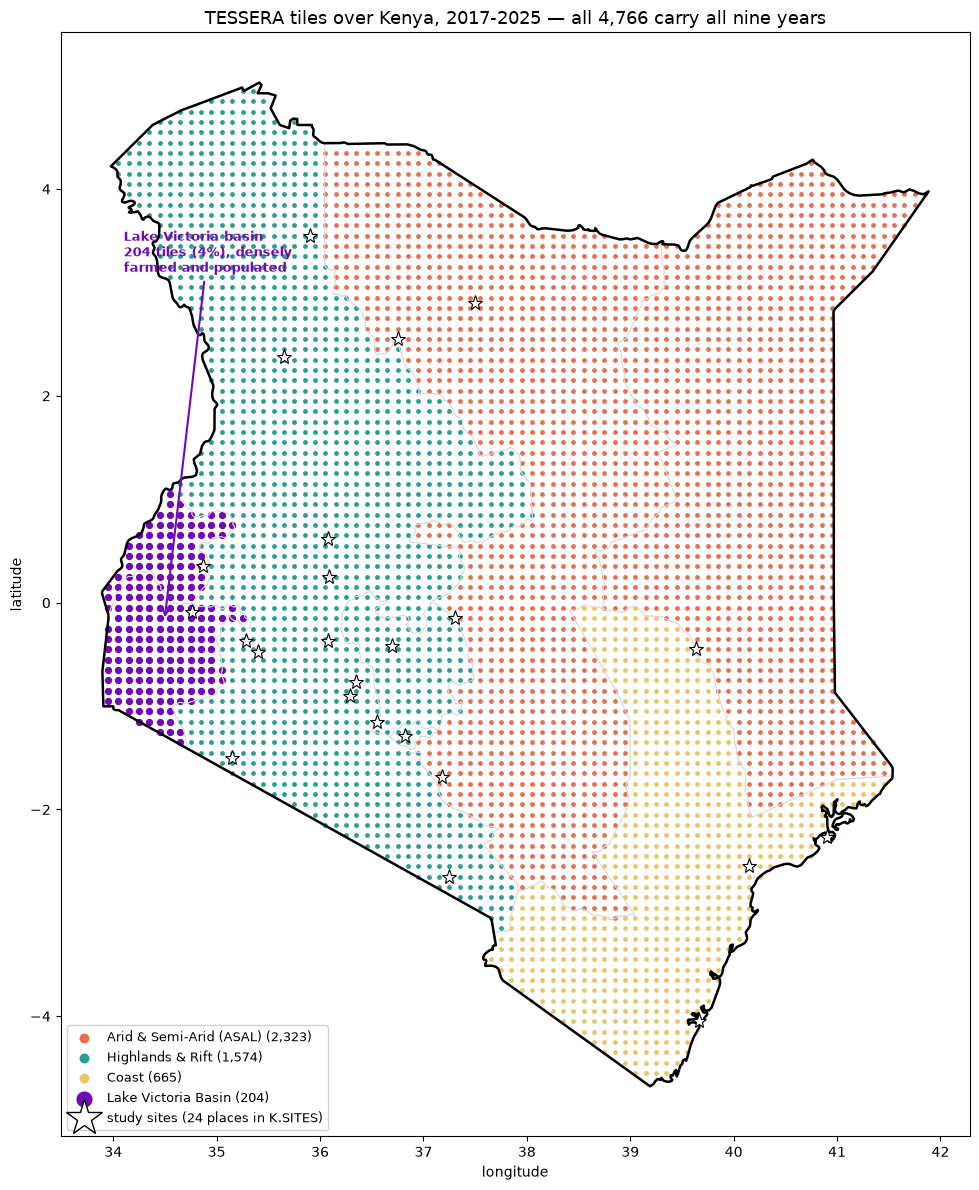

In [6]:
# ---------------------------------------------------------------------------
# THE MAP: every tile, coloured by zone
# ---------------------------------------------------------------------------
# Depth is the same everywhere, so there is nothing to pick out; the map shows
# the zones the rest of the series will sample from, and that they are solid.
adm1 = gpd.read_file(repo_root / "data" / "ne_10m_admin1.geojson")
adm1 = adm1[adm1.admin == "Kenya"]

fig, ax = plt.subplots(figsize=(11, 12))
adm1.boundary.plot(ax=ax, color="0.85", linewidth=0.6)                      # provinces
adm0[adm0.ADMIN == "Kenya"].boundary.plot(ax=ax, color="black", linewidth=1.8)

# Draw biggest zone first so the small ones land on top, and give any zone under
# 600 tiles a larger marker. Without this the Lake Victoria basin — 204 tiles,
# 4%, in one western corner — simply disappears under its neighbours.
for zone in sorted(K.ZONE_COLOURS, key=lambda z: -(cat.zone == z).sum()):
    sub = cat[cat.zone == zone]
    ax.scatter(sub.lon, sub.lat, s=6 if len(sub) > 600 else 18,
               c=K.ZONE_COLOURS[zone], label=f"{zone} ({len(sub):,})")

# Sites this series uses, on top, so their zone context is visible.
for name, (lon, lat, _) in K.SITES.items():
    ax.plot(lon, lat, marker="*", ms=11, mfc="white", mec="black", mew=0.8, zorder=5)

# Point at the smallest zone explicitly — it is the one a reader hunts for.
lvb = cat[cat.zone == "Lake Victoria Basin"]
ax.annotate(f"Lake Victoria basin\n{len(lvb)} tiles ({len(lvb) / len(cat):.0%}), densely\nfarmed and populated",
            xy=(lvb.lon.mean(), lvb.lat.mean()), xytext=(34.1, 3.2),
            fontsize=9, color="#7209b7", weight="bold",
            arrowprops=dict(arrowstyle="->", color="#7209b7", lw=1.5))

ax.set_title("TESSERA tiles over Kenya, 2017-2025 — all 4,766 carry all nine years",
             fontsize=13)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([], [], marker="*", ls="", ms=11, mfc="white", mec="black"))
labels.append(f"study sites ({len(K.SITES)} places in K.SITES)")
ax.legend(handles, labels, loc="lower left", markerscale=2.5, framealpha=0.9, fontsize=9)
plt.tight_layout(); plt.show()

## 3. Pick the place, not the tile

Because every tile has nine years, the workflow runs forwards: choose the site,
then look up its tile. The table below is a check rather than a search: for
each site in `K.SITES`, which tile does it fall in, and how many years does that
tile carry?

In [7]:
# ---------------------------------------------------------------------------
# EVERY SITE, AND THE TILE UNDER IT
# ---------------------------------------------------------------------------
rows = []
for name, (lon, lat, what) in K.SITES.items():
    # Tiles are named by their CENTRE, so a point at (36.82, -1.29) belongs to
    # tile (36.85, -1.25).
    tlon, tlat = K.tile_of(lon, lat)
    own = cat[(cat.lon == tlon) & (cat.lat == tlat)]
    rows.append({
        "site": name,
        "tile": f"({tlon}, {tlat})",
        "years": int(own.n_years.iloc[0]) if len(own) else 0,
        "province": own.province.iloc[0] if len(own) else "not in catalogue",
        "what": what,
    })

sites = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 62)
print(sites.to_string(index=False))

short = sites[sites.years < 9]
print(f"\n{len(sites) - len(short)} of {len(sites)} sites sit on a full nine-year tile.")
if len(short):
    print("exceptions:", ", ".join(short.site))

                          site           tile  years         province                                                                           what
                  Lake Baringo  (36.05, 0.65)      9      Rift Valley                      rift lake that rose ~5 m and flooded its shore after 2010
                  Lake Bogoria  (36.05, 0.25)      9      Rift Valley                                          soda lake, flamingo site, also rising
                   Lake Nakuru (36.05, -0.35)      9      Rift Valley                   national park lake that drowned its own gate and fence lines
                 Lake Naivasha (36.35, -0.75)      9      Rift Valley                      freshwater lake ringed by export floriculture greenhouses
            Olkaria geothermal (36.25, -0.85)      9      Rift Valley                             Africa's largest geothermal field, still expanding
                   Mount Kenya (37.35, -0.15)      9          Eastern               glaciated peak and its

Twenty-three of twenty-four sites sit on a nine-year tile, and the exception is
the clipping artefact from §1 rather than missing data: Mombasa's tile exists
and downloads — §4 fetches it — but its centre falls in the Kilindini channel,
so the polygon test excluded it from the catalogue. Ask the registry, not the
catalogue, and Mombasa has nine years like everywhere else.

So the honest summary of sections 1–3 is that **coverage is not a constraint on
a Kenya programme.** Which makes the next section the one that actually matters.

## 4. The landmask, and the specific way it will mislead you here

TESSERA is a **land** model, and it decides what counts as land using a
landmask. Where that mask says "not land", you do not get an error — you get a
vector of 128 exact zeros, which is not NaN, so `np.isnan` misses it and
`mean()` happily returns a number.

The obvious place this matters is the coast. But Kenya also has **a lot of
inland water**, and water that moves: Lake Victoria, Lake Turkana, and the Rift Valley lakes that
rose several metres over exactly the window TESSERA covers.

So there are two questions here, not one, and they have different answers:

1. What does the mask do at the **sea**?
2. What does it do over an **inland lake**?

The probe below fetches five whole tiles and measures what fraction of each
carries data. This is the first cell that downloads pixels; expect a few
minutes and ~800 MB on a cold cache.

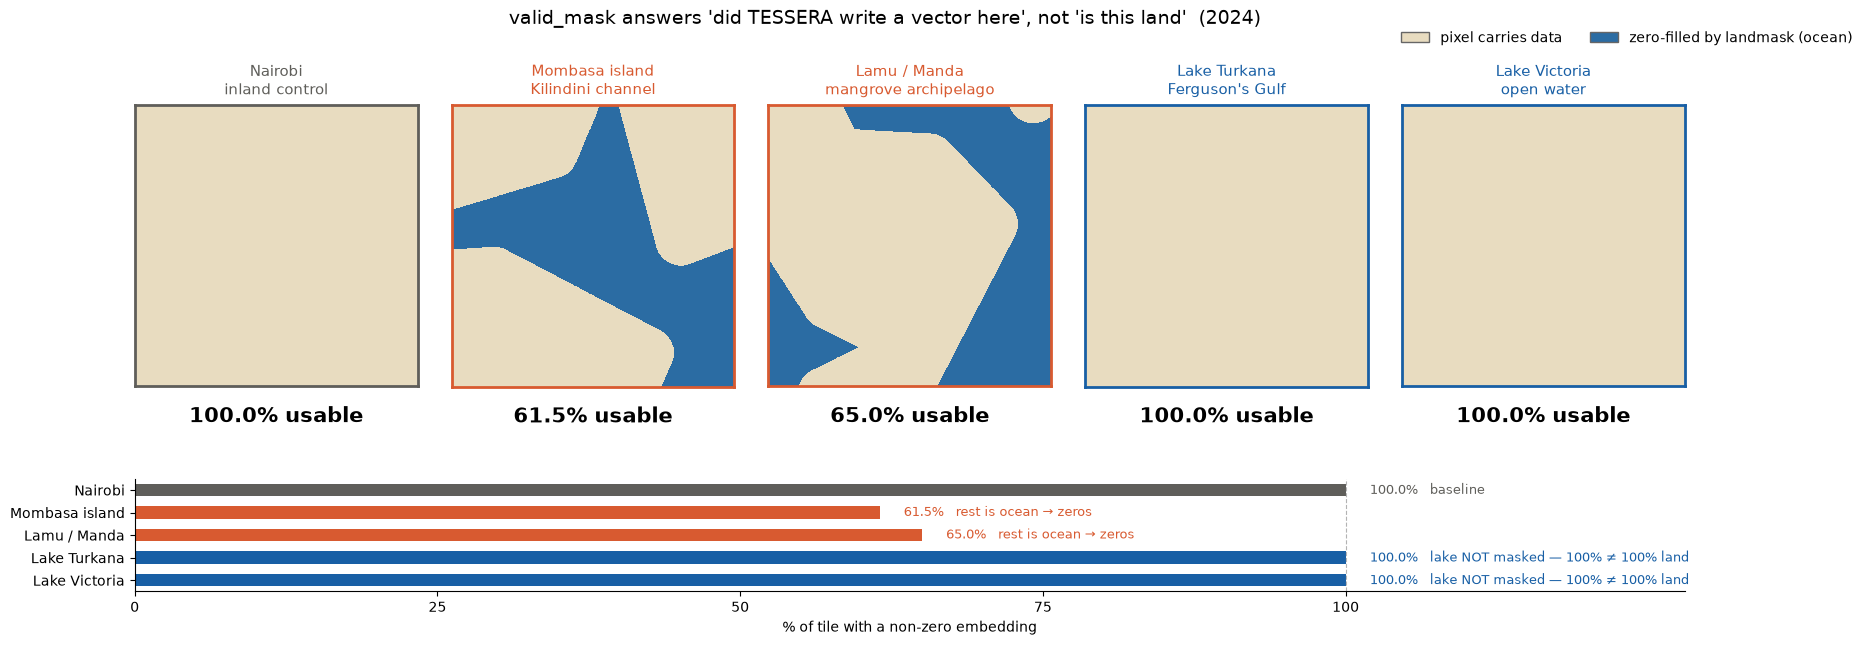

Nairobi (inland control)                      100.00%
Mombasa island (Kilindini channel)             61.51%
Lamu / Manda (mangrove archipelago)            65.00%
Lake Turkana (Ferguson's Gulf)                100.00%
Lake Victoria (open water)                    100.00%


In [8]:
# ---------------------------------------------------------------------------
# HOW MUCH OF EACH TILE IS ACTUALLY DATA?
# ---------------------------------------------------------------------------
probes = [
    (36.85, -1.25, "Nairobi",        "inland control",       "land"),
    (39.65, -4.05, "Mombasa island", "Kilindini channel",    "coast"),
    (40.95, -2.25, "Lamu / Manda",   "mangrove archipelago", "coast"),
    (35.95,  3.55, "Lake Turkana",   "Ferguson's Gulf",      "lake"),
    (33.95, -1.05, "Lake Victoria",  "open water",           "lake"),
]

# masked = steel blue (it is always sea), data = warm sand. Not black/white:
# black reads as "missing" and swamps the panel.
cmap = ListedColormap(["#2b6ca3", "#e8dcc0"])
KIND_C = {"land": "#5F5E5A", "coast": "#D85A30", "lake": "#185FA5"}

fig = plt.figure(figsize=(20, 6.4))
gs = fig.add_gridspec(2, 5, height_ratios=[3.0, 1.15], hspace=0.42, wspace=0.12)

valid_fracs = {}
for i, (lon, lat, name, sub, kind) in enumerate(probes):
    ax = fig.add_subplot(gs[0, i])
    try:
        emb, crs, transform = K.fetch(gt, lon, lat, K.YEAR)
    except Exception as exc:
        ax.text(0.5, 0.5, f"no tile\n{type(exc).__name__}", ha="center", va="center",
                transform=ax.transAxes, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        valid_fracs[name] = None
        continue

    mask = K.valid_mask(emb)
    valid_fracs[name] = float(mask.mean())

    ax.imshow(mask, cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor(KIND_C[kind]); s.set_linewidth(2)
    ax.set_title(f"{name}\n{sub}", fontsize=11, color=KIND_C[kind], pad=8)
    # the number, big, on the image itself
    ax.text(0.5, -0.07, f"{mask.mean():.1%} usable", transform=ax.transAxes,
            ha="center", va="top", fontsize=15, fontweight="bold")

# ---- summary bar: usable % with the interpretation attached ---------------
axb = fig.add_subplot(gs[1, :])
names = [p[2] for p in probes]
kinds = [p[4] for p in probes]
vals = [100 * valid_fracs[n] if valid_fracs[n] is not None else 0 for n in names]

bars = axb.barh(range(len(names))[::-1], vals,
                color=[KIND_C[k] for k in kinds], height=0.55)
axb.set_yticks(range(len(names))[::-1]); axb.set_yticklabels(names, fontsize=10)
axb.set_xlim(0, 128); axb.set_xticks([0, 25, 50, 75, 100])
axb.set_xlabel("% of tile with a non-zero embedding", fontsize=10)
axb.axvline(100, color="0.7", lw=0.8, ls="--")
for s in ("top", "right"): axb.spines[s].set_visible(False)

notes = {"land": "baseline", "coast": "rest is ocean → zeros",
         "lake": "lake NOT masked — 100% ≠ 100% land"}
for bar, k, v in zip(bars, kinds, vals):
    axb.text(v + 2, bar.get_y() + bar.get_height() / 2,
             f"{v:.1f}%   {notes[k]}", va="center", fontsize=9.5, color=KIND_C[k])

fig.legend(handles=[Patch(fc="#e8dcc0", ec="0.4", label="pixel carries data"),
                    Patch(fc="#2b6ca3", ec="0.4", label="zero-filled by landmask (ocean)")],
           loc="upper right", ncol=2, frameon=False, fontsize=10,
           bbox_to_anchor=(0.99, 1.005))
fig.suptitle(f"valid_mask answers 'did TESSERA write a vector here', not 'is this land'  ({K.YEAR})",
             fontsize=14, y=1.02)
plt.show()

for (_, _, name, sub, _) in probes:
    f = valid_fracs[name]
    print(f"{name + ' (' + sub + ')':<45} {'n/a' if f is None else f'{f:>7.2%}'}")

Read those five panels carefully, because they are **two different answers**,
and getting them the wrong way round would quietly ruin a study.

| Tile | Usable | What that means in practice |
|---|---|---|
| Nairobi (inland control) | **100%** | The baseline. Away from the sea there is no problem. |
| Mombasa island | **61.5%** | Nearly 40% of the tile is sea. An unfiltered tile average here is 38% nonsense. |
| Lamu / Manda Bay | **65.0%** | Same story on the archipelago, and this is where the mangroves and the LAPSSET port are. |
| Lake Turkana | **100%** | **The lake is not masked.** Every pixel of the largest desert lake on Earth carries an embedding — and as the next cell shows, 96% of this tile *is* lake. |
| Lake Victoria, open water | **100%** | Ditto. The tile lies entirely on the lake, ~7 km offshore (just across the border, so it is not in the Kenya catalogue). |

**The mask excludes the ocean. It does not exclude inland water.** So
`valid_mask` answers "did TESSERA write a vector here", which is *not* the same
question as "is this land" — and in Kenya, a country with two of Africa's great
lakes and a chain of rift lakes on top of that, the gap between those two
questions is thousands of square kilometres wide.

This cuts both ways, and both directions matter:

- **The opportunity.** Lake pixels carry real, comparable embeddings, so a lake
  that grows into its shoreline is directly observable as a change in the
  embedding at fixed pixels. Kenya's rift lakes did precisely that between 2010
  and 2022 — Baringo, Bogoria, Nakuru and Naivasha all rose several metres and
  drowned roads, schools and park gates. With nine years everywhere, that is
  measurable rather than anecdotal, and §5 takes a first look.
- **The trap.** Any statistic that assumes "valid ⇒ land" is wrong near water.
  Average a Turkana tile for a vegetation claim and most of what you averaged
  was a lake. Neither the shape nor the dtype nor `valid_mask` will warn you.

The next cell confirms the water pixels are real signal rather than filler,
because "100% usable" would look identical if the model had written noise.

water reference vs land reference, cosine: 0.416


land reference vs a second land tile, cosine: 0.744


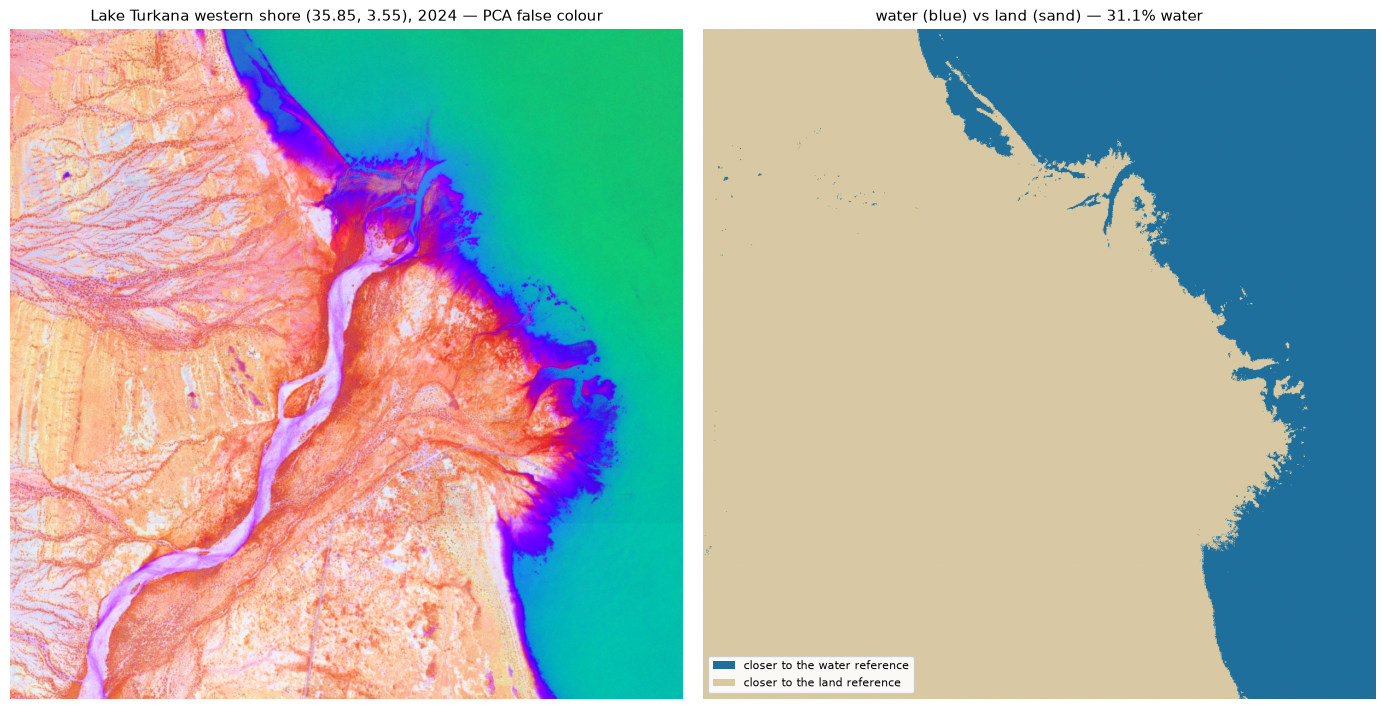


(35.85, 3.55), the shore tile:       31.1% water


(35.95, 3.55), probed in §4:   96.5% water — and it scored 100% 'usable'


In [9]:
# ---------------------------------------------------------------------------
# ARE LAKE PIXELS REAL SIGNAL, OR JUST NON-ZERO?
# ---------------------------------------------------------------------------
# "100% usable" would look identical if the model had written noise over the
# lake. The test: build a water reference and a land reference from two tiles
# whose identity is not in doubt, and check they are far apart. Those two came
# from the probe above and are already cached; the second land tile (a yardstick)
# and the Turkana shore tile below are the only new downloads.
water_ref = K.reference(gt, *K.WATER_REF_TILE)   # open Lake Victoria — certainly water
land_ref  = K.reference(gt, *K.LAND_REF_TILE)    # Nairobi            — certainly land

print(f"water reference vs land reference, cosine: {float(water_ref @ land_ref):.3f}")

# For scale, how similar are two arbitrary LAND tiles to each other? Without
# this the number above is unreadable — cosine on these embeddings does not
# use the full [-1, 1] range.
land_ref2 = K.reference(gt, 34.35, -0.55)     # farmland inland of Homa Bay
print(f"land reference vs a second land tile, cosine: {float(land_ref @ land_ref2):.3f}")

# Now apply the two references: each pixel goes to whichever it resembles more.
# If water is real signal, the result should be a coherent lake with a
# recognisable shoreline, not speckle.
#
# The tile to test this on is (35.85, 3.55) — the western shore of Lake Turkana,
# which is genuinely part land and part water, rather than the (35.95, 3.55)
# tile probed above, which turns out to be almost entirely lake.
def classify(lon, lat):
    emb, _, _ = K.fetch(gt, lon, lat, K.YEAR)
    return K.water_mask(emb, water_ref, land_ref)

SHORE = (35.85, 3.55)
is_water = classify(*SHORE)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
tile = list(gt.fetch_embeddings([(K.YEAR, *SHORE)]))[0]
axes[0].imshow(K.false_colour(gt, tile))
axes[0].set_title(f"Lake Turkana western shore {SHORE}, 2024 — PCA false colour", fontsize=11)

# An explicit two-colour map, because a default colormap would leave the reader
# guessing which end of it meant water.
axes[1].imshow(np.where(is_water, 1, 0), cmap=ListedColormap(["#d8c9a3", "#1f6f9c"]),
               vmin=0, vmax=1)
axes[1].set_title(f"water (blue) vs land (sand) — {is_water.mean():.1%} water", fontsize=11)
axes[1].legend(handles=[Patch(fc="#1f6f9c", label="closer to the water reference"),
                        Patch(fc="#d8c9a3", label="closer to the land reference")],
               loc="lower left", fontsize=8, framealpha=0.9)
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()

print(f"\n{SHORE}, the shore tile:      {is_water.mean():>6.1%} water")
print(f"(35.95, 3.55), probed in §4:  {classify(35.95, 3.55).mean():>6.1%} water "
      f"— and it scored 100% 'usable'")

Water and land sit at cosine **0.42**. The yardstick matters here: two
*unrelated land* tiles — Nairobi and farmland ~290 km away near Homa Bay, with
little in common beyond both being land — sit at **0.74**. So water is
substantially further from land than two quite different landscapes are from
each other, which is the comparison that makes 0.42 mean something.

The map is the stronger evidence, though, because noise cannot fake it. Two
references built from tiles hundreds of kilometres away, applied pixel by pixel
with no spatial smoothing at all, reproduce a single clean shoreline across the
tile. Speckle would mean the water class was meaningless; a coherent coastline
means it is not. The lake is not a hole in the data — it is a surface TESSERA
has a consistent opinion about.

The second printed line sharpens the warning from the table above. The
neighbouring tile `(35.95, 3.55)`, which scored a reassuring **100% usable**,
is **96.5% water** (Natural Earth's lake outline puts it at 92%, so the
classifier and an independent map agree). Anything that averaged it for a claim about vegetation,
soil or land use would be averaging a lake, and would return a perfectly
well-formed number.

## 5. What the nine years actually buy you

One figure to close on, because the whole argument of this notebook is that
Kenya's coverage makes change work routine rather than exceptional.

Lake Baringo is the test case. It is a freshwater rift lake that rose roughly
five metres over the 2010s, pushing water kilometres inland over land that was
farmed and lived on. Tile `(36.05, 0.65)` covers most of the lake and part of its
shore, and it has 2017 and 2025 like every other tile in the country, so the
comparison below is just two fetches and a dot product.

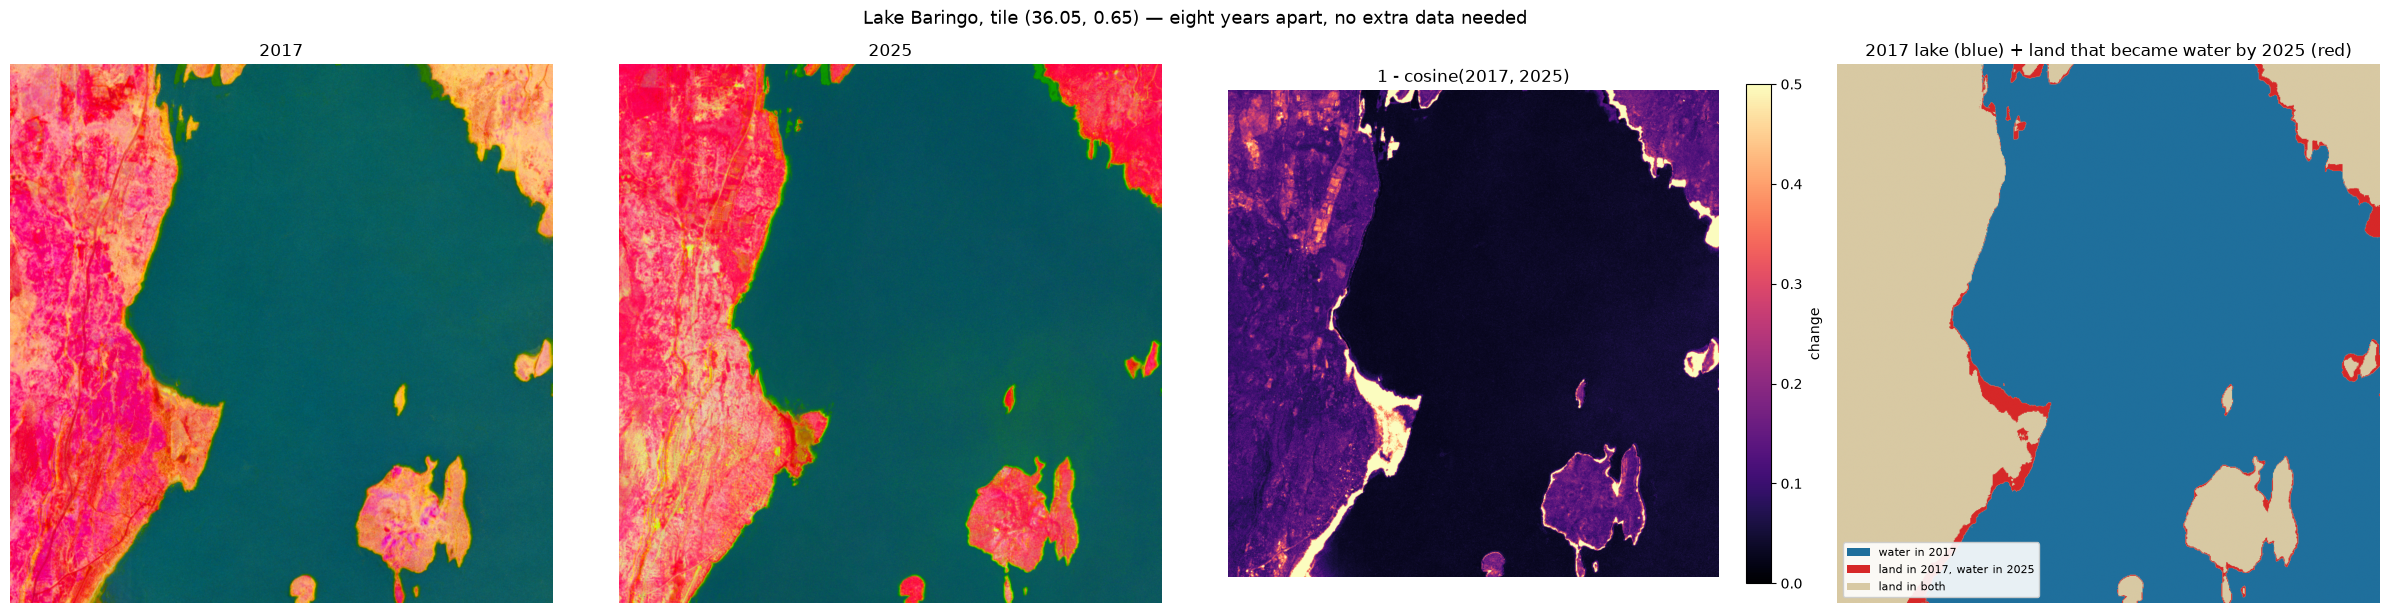

6.8% of the tile changed substantially (1 - cos > 0.2)
water cover: 64.5% in 2017 -> 66.6% in 2025 (+2.6 km^2 in this tile alone)
mean change on land->water pixels: 0.674
mean change everywhere else:       0.076
land->water pixels are 30% of all strongly-changed pixels, on 2.1% of the area

tile centre on satellite imagery: https://www.google.com/maps/@0.65000,36.05000,15z/data=!3m1!1e3


In [10]:
# ---------------------------------------------------------------------------
# LAKE BARINGO, 2017 vs 2025 — per-pixel change from embeddings alone
# ---------------------------------------------------------------------------
LON, LAT = 36.05, 0.65

first, last = K.DEEP_YEARS[0], K.DEEP_YEARS[-1]
emb_a, _, _ = K.fetch(gt, LON, LAT, first)
emb_b, _, _ = K.fetch(gt, LON, LAT, last)

# Same tile, different years: the grids should align pixel for pixel. Check it
# rather than assume it — a mismatch here would silently compare the wrong
# ground, and it is the kind of thing that varies between tiles.
assert emb_a.shape == emb_b.shape, f"grid changed between years: {emb_a.shape} vs {emb_b.shape}"
h, w, _ = emb_a.shape

# Cosine similarity per pixel. Unit-normalising first turns the dot product
# into cosine directly; K.unit leaves masked all-zero rows as zeros rather
# than dividing by zero.
cos = (K.unit(emb_a.reshape(-1, 128)) * K.unit(emb_b.reshape(-1, 128))).sum(1).reshape(h, w)

valid = K.valid_mask(emb_a) & K.valid_mask(emb_b)
change = np.where(valid, 1 - cos, np.nan)      # 0 = identical, 1 = unrecognisable

# Where did the change go? Reuse the §4 references to label each pixel water or
# land in each year — which turns a vague "something changed" into a testable
# claim about the lake specifically.
water_a = K.water_mask(emb_a, water_ref, land_ref)
water_b = K.water_mask(emb_b, water_ref, land_ref)
new_water = (~water_a) & water_b          # was land, is now water

fig, axes = plt.subplots(1, 4, figsize=(24, 6.4))
for ax, year in zip(axes[:2], [first, last]):
    tile = list(gt.fetch_embeddings([(year, LON, LAT)]))[0]
    ax.imshow(K.false_colour(gt, tile))
    ax.set_title(f"{year}", fontsize=12); ax.axis("off")

im = axes[2].imshow(change, cmap="magma", vmin=0, vmax=0.5)
axes[2].set_title(f"1 - cosine({first}, {last})", fontsize=12); axes[2].axis("off")
fig.colorbar(im, ax=axes[2], fraction=0.046, label="change")

axes[3].imshow(np.where(water_a, 1, 0), cmap=ListedColormap(["#d8c9a3", "#1f6f9c"]),
               vmin=0, vmax=1)
# New water on top, as a solid colour rather than a colormap endpoint — the
# whole point of the panel is that this class is unmistakable.
axes[3].imshow(np.where(new_water, 1.0, np.nan),
               cmap=ListedColormap(["#d62828"]), vmin=0, vmax=1)
axes[3].set_title(f"{first} lake (blue) + land that became water by {last} (red)", fontsize=12)
axes[3].legend(handles=[Patch(fc="#1f6f9c", label=f"water in {first}"),
                        Patch(fc="#d62828", label=f"land in {first}, water in {last}"),
                        Patch(fc="#d8c9a3", label="land in both")],
               loc="lower left", fontsize=8, framealpha=0.9)
axes[3].axis("off")

fig.suptitle(f"Lake Baringo, tile ({LON}, {LAT}) — eight years apart, no extra data needed",
             fontsize=13)
plt.tight_layout(); plt.show()

# The numbers behind the pictures.
print(f"{np.nanmean(change > 0.2):.1%} of the tile changed substantially (1 - cos > 0.2)")
print(f"water cover: {water_a.mean():.1%} in {first} -> {water_b.mean():.1%} in {last} "
      f"(+{new_water.mean() * (0.1 * 111.32) ** 2:.1f} km^2 in this tile alone)")
print(f"mean change on land->water pixels: {change[new_water].mean():.3f}")
print(f"mean change everywhere else:       {np.nanmean(change[~new_water]):.3f}")
print(f"land->water pixels are {(big := change > 0.2)[new_water].sum() / big.sum():.0%} "
      f"of all strongly-changed pixels, on {new_water.mean():.1%} of the area")
print(f"\ntile centre on satellite imagery: {K.gmaps(LON, LAT)}")

The lake grew from **64.5% to 66.6% of the tile — about 2.6 km² of new water in
this tile alone** — and the pixels that crossed from land to water changed by
**0.67** on the cosine measure against **0.08** everywhere else, a factor of
nine. On 2% of the area they account for 30% of all the strongly-changed
pixels. The change map is not picking up noise; it is picking up a shoreline
that moved, and it agrees with what is independently known about Baringo.

Two caveats before anyone reads more off it than it holds. Cosine distance
measures "differs from", not "changed for the worse" — it lights up equally for
a lake edge, a new road, and a field that was fallow in one year and planted in
the other, and only the water/land labelling above separates those here. And
two endpoints is the weakest possible design: with nine years available, the
right version of this figure fits a trend per pixel rather than comparing the
ends, which also guards against one anomalous year masquerading as a trend.
That is a job for the next notebook, not this one.

## 6. What this notebook establishes

1. **Kenya is completely covered, in every year TESSERA has.** 4,766 tiles
   inside the border, ~591,000 km² against Kenya's total area of 580,367 km²,
   in each of 2017–2025.

2. **Every tile carries all nine years — 4,766 for 4,766, one identical
   year-list.** Depth is not a variable in Kenya, so no site has to be
   abandoned for lack of years. The record
   also runs to 2025, so "what changed last year" is answerable here.

3. **Coverage is even; the country is not.** 49% of Kenya's tiles are in the
   arid and semi-arid zone and 4% are in the Lake Victoria basin. Any uniform
   sample of tiles is mostly desert, which is a fact about Kenya rather than
   about the dataset — but it will bias anything that samples naively.

4. **The landmask masks the sea and not inland water.** Coastal tiles are
   35–40% zeros (Mombasa 61.5% usable, Lamu 65.0%), while Lake Turkana and open
   Lake Victoria are 100% "usable" — and 96.5% of that Turkana tile is lake.
   The water embeddings are real and self-consistent, not filler: water sits at
   cosine 0.42 from land, where two unrelated land tiles ~290 km apart sit at
   0.74, and the water/land split reproduces Turkana's shoreline.
   `K.valid_mask` therefore answers "is there a vector here", not "is this
   land", and in Kenya those differ across thousands of km². Filter
   accordingly, and exploit it when the lake *is* the subject.

5. **The nine years are immediately usable.** A two-line comparison of Lake
   Baringo's 2017 and 2025 tiles recovers its documented expansion — water
   cover 64.5% → 66.6%, ~2.6 km² of new water in one tile, with land-to-water
   pixels changing nine times as much as everything else.

6. **Clip by centre with care.** The catalogue keeps tiles whose centre falls
   inside the Natural Earth polygon, which drops genuinely Kenyan coastal tiles
   — Mombasa's among them. On the coast, query `gt.registry` directly.

The practical consequence: no notebook here needs to be designed around what
data exists. Change detection, multi-year trends and
national-scale mosaics are all in scope from the start, and the questions worth
building on this are the ones where nine years of everywhere is the point —
the rift lakes, the Mau and Aberdare forest belts, peri-urban Nairobi, the ASAL
drought cycles, and the infrastructure corridors (SGR, LAPSSET, Lake Turkana
Wind Power) that were all built inside the window.